<a href="https://colab.research.google.com/github/arni-007/RUGVED/blob/main/Final_RL_task_Naman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Buddy Finds Rover — Q-Learning vs DQN vs PPO

Three agents, one maze. Buddy starts at `(0,0)` and must reach Rover at `(9,9)`, collecting bone treats at `(3,5)` and `(9,3)` along the way.

```
[ B,  0,  1,  1,  1,  1,  1,  1,  1,  1 ]
[ 1,  1,  1,  1,  1,  0,  1,  1,  1,  1 ]
[ 1,  1,  1,  1,  1,  0,  1,  1,  1,  1 ]
[ 0,  0,  1,  0,  0,  T,  0,  1,  1,  1 ]   T = Treat
[ 1,  1,  0,  1,  0,  1,  0,  0,  0,  1 ]
[ 1,  1,  0,  1,  0,  1,  1,  1,  1,  1 ]
[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1 ]
[ 1,  1,  1,  1,  1,  1,  0,  0,  0,  0 ]
[ 1,  0,  0,  0,  0,  0,  1,  1,  1,  1 ]
[ 1,  1,  1,  T,  1,  1,  1,  0,  1,  R ]   R = Rover
```

## Cell 1 — Installs & Imports

In [1]:
!pip install gymnasium stable-baselines3[extra] -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from collections import deque
import random, time, warnings
warnings.filterwarnings('ignore')

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env

print('All imports successful.')

All imports successful.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Cell 2 — Maze Setup

In [2]:
RAW = np.array([
    ['B',  0,   1,   1,   1,   1,   1,   1,   1,   1 ],
    [ 1,   1,   1,   1,   1,   0,   1,   1,   1,   1 ],
    [ 1,   1,   1,   1,   1,   0,   1,   1,   1,   1 ],
    [ 0,   0,   1,   0,   0,  'T',  0,   1,   1,   1 ],
    [ 1,   1,   0,   1,   0,   1,   0,   0,   0,   1 ],
    [ 1,   1,   0,   1,   0,   1,   1,   1,   1,   1 ],
    [ 1,   1,   1,   1,   1,   1,   1,   1,   1,   1 ],
    [ 1,   1,   1,   1,   1,   1,   0,   0,   0,   0 ],
    [ 1,   0,   0,   0,   0,   0,   1,   1,   1,   1 ],
    [ 1,   1,   1,  'T',  1,   1,   1,   0,   1,  'R'],
], dtype=object)

GRID = np.zeros((10, 10), dtype=np.int32)
TREATS, START, GOAL = [], None, None

for r in range(10):
    for c in range(10):
        v = RAW[r, c]
        if   v == 'B': START = (r, c); GRID[r, c] = 1
        elif v == 'R': GOAL  = (r, c); GRID[r, c] = 1
        elif v == 'T': TREATS.append((r, c)); GRID[r, c] = 1
        else:          GRID[r, c] = int(v != 0)

DIRS     = [(-1,0),(1,0),(0,-1),(0,1)]   # up, down, left, right
N_TREATS = len(TREATS)

def can_walk(r, c):
    return 0 <= r < 10 and 0 <= c < 10 and GRID[r,c] == 1

print(f'Start : {START}  |  Goal : {GOAL}  |  Treats : {TREATS}')

Start : (0, 0)  |  Goal : (9, 9)  |  Treats : [(3, 5), (9, 3)]


## Cell 3 — Maze Visualizer

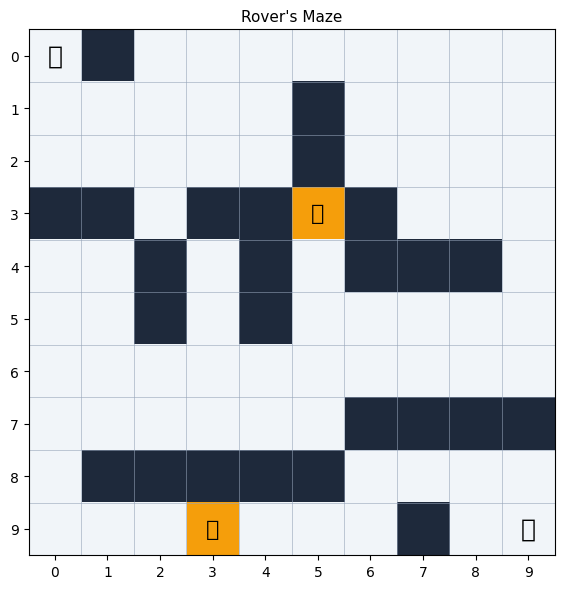

In [3]:
def draw_maze(path=None, title='Maze', ax=None, treat_mask=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6,6))
    if treat_mask is None:
        treat_mask = [False] * N_TREATS

    display = np.where(GRID==0, -1, 0).astype(float)
    for i,(tr,tc) in enumerate(TREATS):
        if not treat_mask[i]: display[tr,tc] = 2

    ax.imshow(display, cmap=ListedColormap(['#1e293b','#f1f5f9','#f59e0b']),
              vmin=-1, vmax=2, interpolation='nearest')

    if path and len(path) > 1:
        rs = [p[0] for p in path]; cs = [p[1] for p in path]
        ax.plot(cs, rs, color='#3b82f6', lw=2.5, alpha=0.7)
        ax.plot(cs[0], rs[0], 'o', color='#22c55e', ms=9)

    ax.text(START[1], START[0], '🐶', ha='center', va='center', fontsize=18)
    ax.text(GOAL[1],  GOAL[0],  '🐕', ha='center', va='center', fontsize=18)
    for i,(tr,tc) in enumerate(TREATS):
        if not treat_mask[i]: ax.text(tc, tr, '🦴', ha='center', va='center', fontsize=16)

    for x in range(11): ax.axvline(x-0.5, color='#94a3b8', lw=0.4)
    for y in range(11): ax.axhline(y-0.5, color='#94a3b8', lw=0.4)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_title(title, fontsize=11)
    if standalone: plt.tight_layout(); plt.show()

draw_maze(title="Rover's Maze")

## Cell 4 — Gymnasium Environment

In [4]:
class RoverMazeEnv(gym.Env):
    """
    Gymnasium environment for the Rover maze.
    Fixed reward shaping — agent must actually reach GOAL to get the big reward.
    """
    metadata = {'render_modes': []}

    def __init__(self, max_steps=300):
        super().__init__()
        self.max_steps = max_steps
        self.observation_space = spaces.Box(
            low=np.zeros(8, dtype=np.float32),
            high=np.ones(8, dtype=np.float32), dtype=np.float32)
        self.action_space = spaces.Discrete(4)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.r, self.c  = START
        self.got        = [False] * N_TREATS
        self.steps_done = 0
        self.path       = [START]
        self._prev_dist = abs(self.r - GOAL[0]) + abs(self.c - GOAL[1])
        return self._obs(), {}

    def step(self, action):
        info={}
        dr, dc = DIRS[int(action)]
        nr, nc = self.r + dr, self.c + dc
        if not can_walk(nr, nc):
            nr, nc = self.r, self.c
            reward = -0.5                      # wall hit penalty
        else:
            reward = -0.05                     # small step cost

        # Treat pickup
        for i,(tr,tc) in enumerate(TREATS):
            if not self.got[i] and (nr,nc) == (tr,tc):
                self.got[i] = True
                reward += 10.0

        # Goal reached — BIG reward, make it unambiguous
        terminated = False
        if (nr,nc) == GOAL:
            reward += 50.0 + sum(10.0 for g in self.got if g)
            terminated = True
            info["is_success"] = True # Add this

        self.r, self.c   = nr, nc
        self.steps_done += 1
        self.path.append((self.r, self.c))

        truncated = self.steps_done >= self.max_steps
        return self._obs(), reward, terminated, truncated,info

    def _obs(self):
        walls = [
            float(not can_walk(self.r-1, self.c)),
            float(not can_walk(self.r+1, self.c)),
            float(not can_walk(self.r, self.c-1)),
            float(not can_walk(self.r, self.c+1)),
        ]
        return np.array(
            [self.r/9.0, self.c/9.0] + [float(g) for g in self.got] + walls,
            dtype=np.float32
        )

check_env(RoverMazeEnv(), warn=True)
print('Environment check passed.')
env = RoverMazeEnv()
obs, _ = env.reset()
print(f'Obs shape: {obs.shape}  |  Action space: {env.action_space}')

Environment check passed.
Obs shape: (8,)  |  Action space: Discrete(4)


## Cell 5 — Training Callback (shared by all agents)

In [5]:
class TrainingLogger(BaseCallback):
    """Records per-episode reward, steps, loss and success rate."""

    def __init__(self, print_every=100, agent_name='Agent'):
        super().__init__()
        self.print_every = print_every
        self.agent_name  = agent_name
        self.ep_rewards  = []
        self.ep_steps    = []
        self.ep_losses   = []
        self.acc_log     = []
        self._ep_reward  = 0.0
        self._ep_steps   = 0
        self._ep_losses  = []
        self._ep_count   = 0
        self._successes  = deque(maxlen=100)

    def _on_step(self):
        self._ep_reward += self.locals['rewards'][0]
        self._ep_steps  += 1
        loss = self.model.logger.name_to_value.get('train/loss')
        if loss is not None: self._ep_losses.append(loss)


        if self.locals['dones'][0]:
            self._ep_count += 1
            # Check the info dict for the success flag instead of coordinates
            info = self.locals['infos'][0]
            reached = info.get("is_success", False)
            self._successes.append(int(reached))

            avg_loss = float(np.mean(self._ep_losses)) if self._ep_losses else 0.0
            acc      = 100.0 * np.mean(self._successes)
            self.ep_rewards.append(self._ep_reward)
            self.ep_steps.append(self._ep_steps)
            self.ep_losses.append(avg_loss)
            self.acc_log.append(acc)

            if self._ep_count % self.print_every == 0 or self._ep_count == 1:
                eps = getattr(self.model, 'exploration_rate', '-')
                eps_str = f'{eps:.3f}' if isinstance(eps, float) else eps
                result  = 'REACHED ROVER ✓' if reached else 'failed'
                print(f'[{self.agent_name}] Ep {self._ep_count:>4} | '
                      f'ε {eps_str:>5} | Reward {self._ep_reward:>8.2f} | '
                      f'Steps {self._ep_steps:>4} | Acc {acc:>5.1f}% | {result}')

            self._ep_reward = 0.0; self._ep_steps = 0; self._ep_losses = []
        return True

print('Callback defined.')

Callback defined.


## Cell 6 — Agent 1: Tabular Q-Learning

Classic Q-Learning stores a table of size `states × actions`. Because the state space here is continuous, we discretize it into a grid of buckets. This is the simplest RL algorithm — no neural network, no SB3, just numpy.

**How it works:** `Q(s,a) ← Q(s,a) + α [r + γ·max Q(s',·) − Q(s,a)]`

In [6]:
# ── Tabular Q-Learning (custom, no SB3 needed) ────────────────────────────
# State = (row, col, treat0, treat1) — fully discrete, no bucketing needed

QL_EPISODES  = 2500
QL_MAX_STEPS = 300
QL_ALPHA     = 0.3     # learning rate
QL_GAMMA     = 0.97    # discount
QL_EPS_START = 1.0
QL_EPS_END   = 0.05
QL_EPS_DECAY = 0.999

# Q-table: [row, col, treat0, treat1, action]
Q = np.zeros((10, 10, 2, 2, 4), dtype=np.float32)

def ql_state(env):
    return (env.r, env.c, int(env.got[0]), int(env.got[1]))

ql_rewards, ql_acc, ql_steps_log = [], [], []
ql_successes = deque(maxlen=100)
ql_best_path, ql_best_reward = None, -np.inf
ql_eps = QL_EPS_START

print('Training Q-Learning...')
print(f'{"Ep":>5} | {"ε":>5} | {"Reward":>8} | {"Steps":>5} | {"Acc%":>6} | Result')
print('-' * 55)

ql_env = RoverMazeEnv(max_steps=QL_MAX_STEPS)
t0 = time.time()

for ep in range(1, QL_EPISODES+1):
    ql_env.reset()
    s       = ql_state(ql_env)
    ep_r    = 0.0
    ep_steps = 0

    for _ in range(QL_MAX_STEPS):
        # ε-greedy
        if random.random() < ql_eps:
            a = random.randint(0,3)
        else:
            a = int(np.argmax(Q[s]))

        _, r, terminated, truncated, _ = ql_env.step(a)
        s2    = ql_state(ql_env)
        done  = terminated or truncated

        # Bellman update
        Q[s][a] += QL_ALPHA * (r + QL_GAMMA * np.max(Q[s2]) * (1-int(terminated)) - Q[s][a])
        s        = s2
        ep_r    += r
        ep_steps += 1
        if done: break

    ql_eps = max(QL_EPS_END, ql_eps * QL_EPS_DECAY)
    reached = (ql_env.r, ql_env.c) == GOAL
    ql_successes.append(int(reached))
    acc = 100.0 * np.mean(ql_successes)

    ql_rewards.append(ep_r)
    ql_acc.append(acc)
    ql_steps_log.append(ep_steps)

    if reached and ep_r > ql_best_reward:
        ql_best_reward = ep_r
        ql_best_path   = list(ql_env.path)

    if ep % 500 == 0 or ep == 1:
        result = 'REACHED ROVER ✓' if reached else 'failed'
        print(f'{ep:>5} | {ql_eps:>5.3f} | {ep_r:>8.2f} | {ep_steps:>5} | {acc:>5.1f}% | {result}')

ql_time = time.time() - t0
print(f'\nQ-Learning done in {ql_time:.1f}s | Final accuracy: {ql_acc[-1]:.1f}%')

Training Q-Learning...
   Ep |     ε |   Reward | Steps |   Acc% | Result
-------------------------------------------------------
    1 | 0.999 |   -47.85 |   300 |   0.0% | failed
  500 | 0.606 |    74.80 |    88 |  99.0% | REACHED ROVER ✓
 1000 | 0.368 |    84.70 |    61 | 100.0% | REACHED ROVER ✓
 1500 | 0.223 |    86.30 |    47 | 100.0% | REACHED ROVER ✓
 2000 | 0.135 |    87.10 |    49 | 100.0% | REACHED ROVER ✓
 2500 | 0.082 |    87.20 |    47 | 100.0% | REACHED ROVER ✓

Q-Learning done in 11.4s | Final accuracy: 100.0%


## Cell 7 — Agent 2: DQN (Stable-Baselines3)



In [7]:
DQN_TIMESTEPS = 150_000

dqn_env = Monitor(RoverMazeEnv())

dqn_model = DQN(
    policy                  = 'MlpPolicy',
    env                     = dqn_env,
    learning_rate           = 5e-4,
    buffer_size             = 50_000,
    learning_starts         = 5000,        # wait for buffer diversity
    batch_size              = 128,
    gamma                   = 0.99,
    train_freq              = 4,
    target_update_interval  = 1000,
    exploration_fraction    = 0.4,
    exploration_initial_eps = 1.0,
    exploration_final_eps   = 0.05,
    policy_kwargs           = dict(net_arch=[128, 128]),
    verbose                 = 0,
)

dqn_logger = TrainingLogger(print_every=100, agent_name='DQN')
print(f'Training DQN for {DQN_TIMESTEPS:,} timesteps...\n')

t0 = time.time()
dqn_model.learn(total_timesteps=DQN_TIMESTEPS, callback=dqn_logger, progress_bar=True)
dqn_time = time.time() - t0

print(f'\nDQN done in {dqn_time:.1f}s | Final accuracy: {dqn_logger.acc_log[-1]:.1f}%')

# Get best DQN path
def get_best_path(model, n_runs=30):
    best_path, best_reward, best_got = None, -np.inf, None
    for _ in range(n_runs):
        e = RoverMazeEnv()
        obs, _ = e.reset()
        done, total = False, 0.0
        while not done:
            a, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = e.step(int(a))
            total += r
            done   = term or trunc
        if (e.r, e.c) == GOAL and total > best_reward:
            best_reward = total
            best_path   = list(e.path)
            best_got    = list(e.got)
    return best_path, best_reward, best_got

dqn_best_path, dqn_best_reward, dqn_best_got = get_best_path(dqn_model)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

[DQN] Ep    1 | ε 0.995 | Reward   -57.30 | Steps  300 | Acc   0.0% | failed

Training DQN for 150,000 timesteps...



...

[DQN] Ep 1900 | ε 0.050 | Reward    87.70 | Steps   46 | Acc 100.0% | REACHED ROVER ✓

[DQN] Ep 2000 | ε 0.050 | Reward    86.70 | Steps   48 | Acc 100.0% | REACHED ROVER ✓

[DQN] Ep 2100 | ε 0.050 | Reward    87.70 | Steps   46 | Acc 100.0% | REACHED ROVER ✓

[DQN] Ep 2200 | ε 0.050 | Reward    86.60 | Steps   50 | Acc 100.0% | REACHED ROVER ✓


DQN done in 253.4s | Final accuracy: 100.0%


## Cell 8 — Agent 3: PPO (Stable-Baselines3)

PPO (Proximal Policy Optimization) is an on-policy algorithm. Instead of a Q-value table or network, it learns a **policy directly** — a probability distribution over actions. It updates using multiple small gradient steps per batch of fresh experience, clipping updates so they don't overshoot.


In [8]:
PPO_TIMESTEPS = 500_000

ppo_env = Monitor(RoverMazeEnv())

ppo_model = PPO(
    policy        = 'MlpPolicy',
    env           = ppo_env,
    learning_rate = 3e-4,
    n_steps       = 4096,    # steps per rollout batch
    batch_size    = 64,
    n_epochs      = 5,      # gradient steps per batch
    gamma         = 0.99,
    gae_lambda    = 0.95,    # GAE smoothing
    clip_range    = 0.3,     # PPO clip (the 'proximal' part)
    ent_coef      = 0.01,    # entropy bonus — keeps policy exploring
    policy_kwargs = dict(net_arch=[dict(pi=[128,128], vf=[128,128])]),
    verbose       = 0,
)

ppo_logger = TrainingLogger(print_every=100, agent_name='PPO')
print(f'Training PPO for {PPO_TIMESTEPS:,} timesteps...\n')

t0 = time.time()
ppo_model.learn(total_timesteps=PPO_TIMESTEPS, callback=ppo_logger, progress_bar=True)
ppo_time = time.time() - t0

print(f'\nPPO done in {ppo_time:.1f}s | Final accuracy: {ppo_logger.acc_log[-1]:.1f}%')

ppo_best_path, ppo_best_reward, ppo_best_got = get_best_path(ppo_model)

Output()

Training PPO for 500,000 timesteps...



[PPO] Ep    1 | ε     - | Reward   -55.95 | Steps  300 | Acc   0.0% | failed

[PPO] Ep  100 | ε     - | Reward   -15.45 | Steps  300 | Acc   0.0% | failed

[PPO] Ep  200 | ε     - | Reward   -15.00 | Steps  300 | Acc   0.0% | failed

...

[PPO] Ep 1300 | ε     - | Reward   -15.00 | Steps  300 | Acc   0.0% | failed

[PPO] Ep 1400 | ε     - | Reward   -15.00 | Steps  300 | Acc   0.0% | failed

[PPO] Ep 1500 | ε     - | Reward   -15.00 | Steps  300 | Acc   0.0% | failed

[PPO] Ep 1600 | ε     - | Reward   -15.00 | Steps  300 | Acc   0.0% | failed


PPO done in 809.3s | Final accuracy: 0.0%


## Cell 9 — Training Curves: All Three Agents

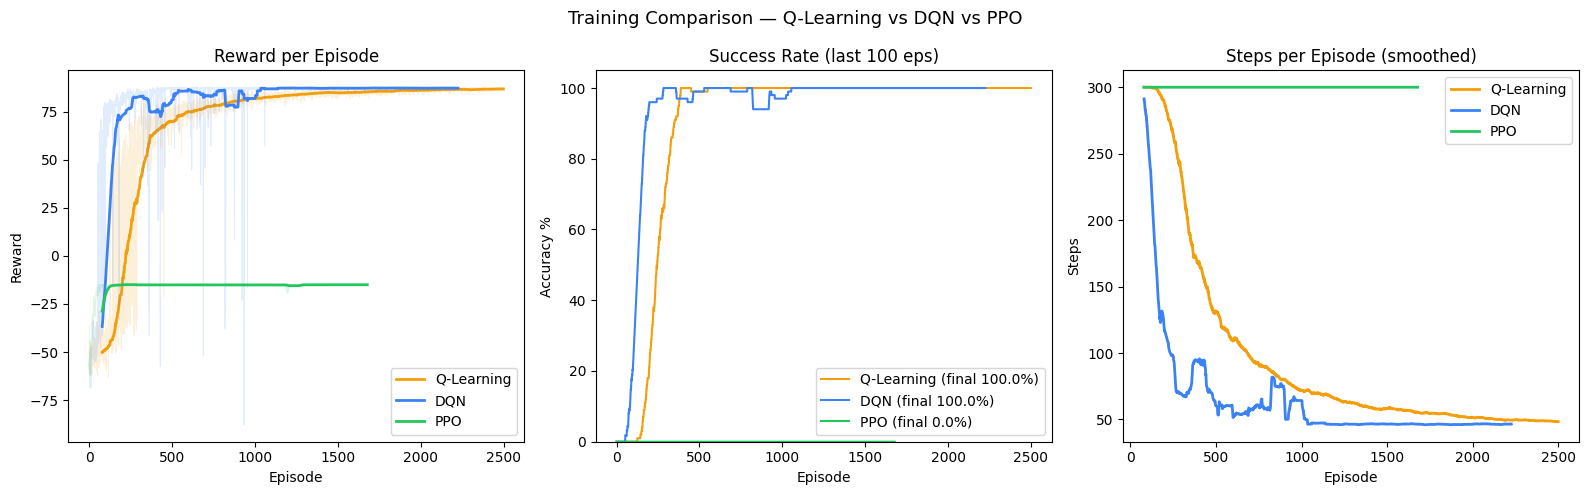

In [13]:
def smooth(data, w=80):
    if len(data) < w: return np.array(data)
    return np.convolve(data, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Training Comparison — Q-Learning vs DQN vs PPO', fontsize=13)

agents = [
    ('Q-Learning', ql_rewards,          ql_acc,          '#f59e0b'),
    ('DQN',        dqn_logger.ep_rewards, dqn_logger.acc_log, '#3b82f6'),
    ('PPO',        ppo_logger.ep_rewards, ppo_logger.acc_log, '#22c55e'),
]

# Reward
ax = axes[0]
for name, rewards, _, color in agents:
    ax.plot(rewards, color=color, alpha=0.15, lw=0.7)
    sm = smooth(rewards)
    ax.plot(range(len(rewards)-len(sm), len(rewards)), sm, color=color, lw=2, label=name)
ax.set_title('Reward per Episode'); ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.legend()

# Accuracy
ax = axes[1]
for name, _, acc, color in agents:
    ax.plot(acc, color=color, lw=1.5, label=f'{name} (final {acc[-1]:.1f}%)')
ax.set_title('Success Rate (last 100 eps)'); ax.set_xlabel('Episode'); ax.set_ylabel('Accuracy %')
ax.set_ylim(0, 105); ax.legend()

# Steps per episode
ax = axes[2]
for name, _, _, color in agents:
    if name == 'Q-Learning': steps = ql_steps_log
    elif name == 'DQN':      steps = dqn_logger.ep_steps
    else:                    steps = ppo_logger.ep_steps
    sm = smooth(steps)
    ax.plot(range(len(steps)-len(sm), len(steps)), sm, color=color, lw=2, label=name)
ax.set_title('Steps per Episode (smoothed)'); ax.set_xlabel('Episode'); ax.set_ylabel('Steps')
ax.legend()

plt.tight_layout(); plt.show()

## Cell 10 — Final Paths: Side-by-Side Comparison

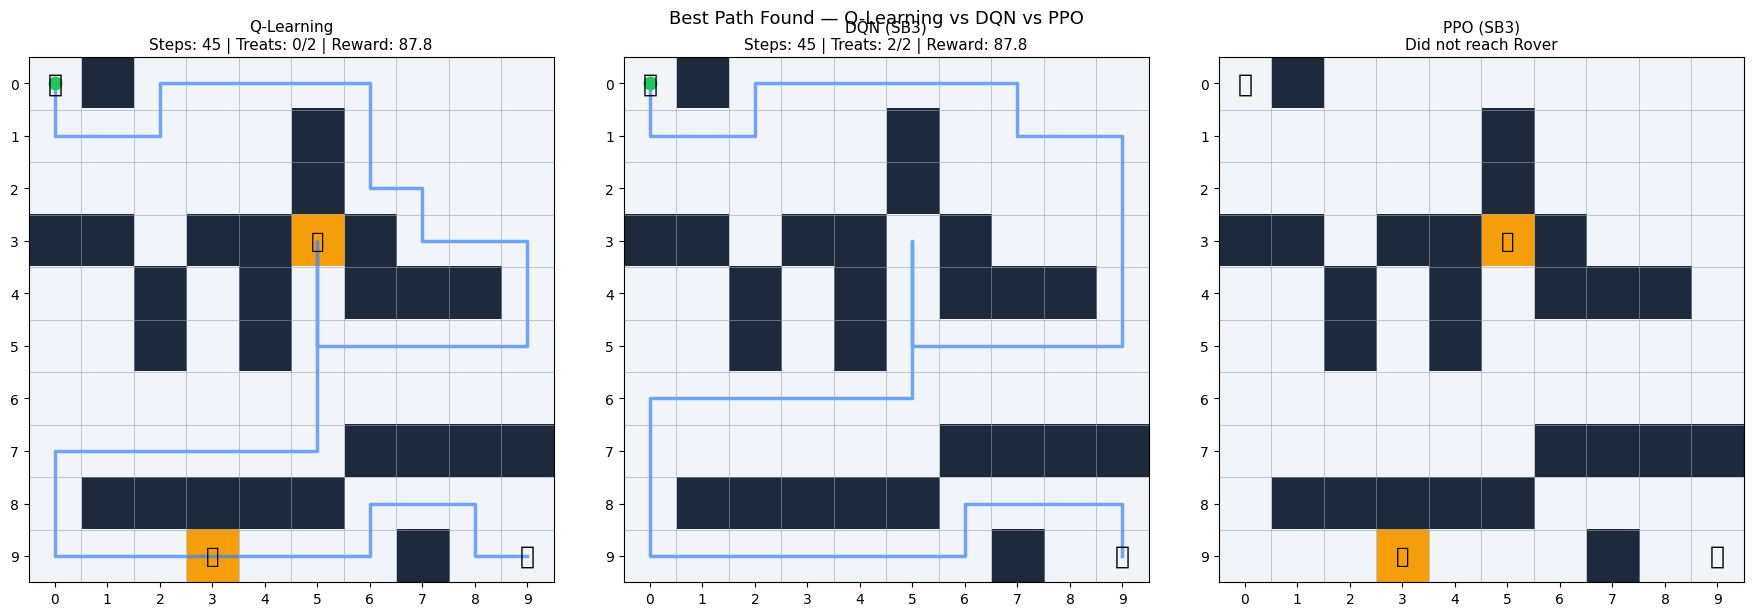

In [14]:
paths = [
    ('Q-Learning', ql_best_path,  [False]*N_TREATS, ql_best_reward),
    ('DQN (SB3)',  dqn_best_path, dqn_best_got or [False]*N_TREATS, dqn_best_reward),
    ('PPO (SB3)',  ppo_best_path, ppo_best_got or [False]*N_TREATS, ppo_best_reward),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Best Path Found — Q-Learning vs DQN vs PPO', fontsize=13)

for ax, (name, path, got, reward) in zip(axes, paths):
    if path:
        treats_found = sum(got)
        title = f'{name}\nSteps: {len(path)} | Treats: {treats_found}/{N_TREATS} | Reward: {reward:.1f}'
    else:
        title = f'{name}\nDid not reach Rover'
    draw_maze(path=path, title=title, ax=ax, treat_mask=got)

plt.tight_layout(); plt.show()

## Cell 11 — Summary Comparison Table

In [15]:
print('=' * 65)
print(f'{"Metric":<28} {"Q-Learning":>10} {"DQN":>10} {"PPO":>10}')
print('=' * 65)

def path_len(p): return len(p) if p else 'N/A'
def reached(p):  return 'Yes ✓' if p else 'No ✗'
def final_acc(a): return f'{a[-1]:.1f}%'
def train_t(t):  return f'{t:.0f}s'

rows = [
    ('Reached Rover',     reached(ql_best_path),  reached(dqn_best_path),  reached(ppo_best_path)),
    ('Final accuracy',    final_acc(ql_acc),       final_acc(dqn_logger.acc_log), final_acc(ppo_logger.acc_log)),
    ('Best path (steps)', path_len(ql_best_path),  path_len(dqn_best_path), path_len(ppo_best_path)),
    ('Training time',     train_t(ql_time),        train_t(dqn_time),       train_t(ppo_time)),
]

for label, ql, dqn, ppo in rows:
    print(f'{label:<28} {str(ql):>10} {str(dqn):>10} {str(ppo):>10}')

print('=' * 65)

Metric                       Q-Learning        DQN        PPO
Reached Rover                     Yes ✓      Yes ✓       No ✗
Final accuracy                   100.0%     100.0%       0.0%
Best path (steps)                    45         45        N/A
Training time                       11s       253s       809s
